Imports

In [ ]:
import pandas as pd
import kagglehub
import os
import matplotlib.pyplot as plt
import numpy as np

# Download latest version
path = kagglehub.dataset_download("diaaessam/exoplanets-planets-outside-our-galaxy")

print("Path to dataset files:", path)
# Check csv file path
print(os.listdir(path))

file_path = os.path.join(path, "exoplanets.csv")  # Replace with actual file name




100%|██████████| 130k/130k [00:00<00:00, 453kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/diaaessam/exoplanets-planets-outside-our-galaxy/versions/2
['exoplanets.csv']


Read file

In [ ]:
data = pd.read_csv(file_path)
print(data.head())


                 Name Mass (MJ) Radius (RJ) Period (days)  \
0         16 Cygni Bb      2.38         NaN         799.5   
1         23 Librae b      1.61         NaN        258.18   
2  47 Ursae Majoris b      2.53         NaN          1078   
3         51 Pegasi b      0.46         NaN      4.230785   
4         55 Cancri b    0.8306         NaN      14.65152   

  Semi-major axis (AU) Temp. (K) Discovery method  Disc. Year Distance (ly)  \
0                 1.66       NaN      radial vel.      1996.0         68.99   
1                 0.81       NaN      radial vel.      1999.0         85.46   
2                  2.1       NaN      radial vel.      1996.0         45.02   
3               0.0527       NaN      radial vel.      1995.0         50.45   
4             0.115227       700      radial vel.      1996.0         41.06   

  Host star mass (M☉) Host star temp. (K)  \
0                1.04                5750   
1                1.07                5736   
2                1.08  

Clean data

In [ ]:
!pip install pandas numpy matplotlib seaborn
pd.set_option('display.max_columns', None)
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4855 entries, 0 to 4854
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Name                  4855 non-null   object 
 1   Mass (MJ)             2295 non-null   object 
 2   Radius (RJ)           3700 non-null   object 
 3   Period (days)         4637 non-null   object 
 4   Semi-major axis (AU)  3148 non-null   object 
 5   Temp. (K)             1094 non-null   object 
 6   Discovery method      4855 non-null   object 
 7   Disc. Year            411 non-null    float64
 8   Distance (ly)         4706 non-null   object 
 9   Host star mass (M☉)   4475 non-null   object 
 10  Host star temp. (K)   4513 non-null   object 
 11  Remarks               4502 non-null   object 
dtypes: float64(1), object(11)
memory usage: 455.3+ KB


,Disc. Year
count,411.000000
mean,2005.313869
std,3.639389
min,1988.000000
25%,2003.000000
50%,2006.000000
75%,2008.000000
max,2009.000000


Missing values

In [ ]:
data.isnull().sum()  # Check for missing values


,0
Name,0
Mass (MJ),2560
Radius (RJ),1155
Period (days),218
Semi-major axis (AU),1707
Temp. (K),3761
Discovery method,0
Disc. Year,4444
Distance (ly),149
Host star mass (M☉),380


Remove rows with missing values and choose relevant columns to plot

In [ ]:
data_cleaned = data.dropna(subset=['Semi-major axis (AU)', 'Temp. (K)'])
sample_data = data_cleaned.sample(n=200)
X = sample_data ['Semi-major axis (AU)']
Y = sample_data ['Temp. (K)']
Y


,Temp. (K)
4449,"1,371±14"
3916,664.5+8.0−7.7
833,670±35
4137,1037±11
4753,1458+20−17
...,...
4676,1860±20
4187,351
4206,1033±19
653,427


plotting semi-majoy axis vs. temperature

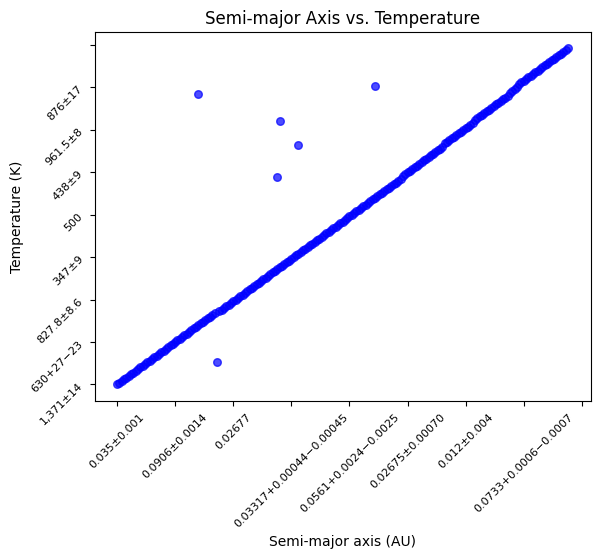

Archivo guardado correctamente en: /content/sample_data/sample.html


In [ ]:
!pip install plotly

from matplotlib.ticker import MaxNLocator
import plotly.express as px
import pandas as pd
fig = plt.scatter(X, Y, c='blue', alpha=0.7, s=30)

plt.xlabel('Semi-major axis (AU)')
plt.ylabel('Temperature (K)')
plt.title('Semi-major Axis vs. Temperature')
plt.xticks(rotation=45, fontsize=8)  # Rotar etiquetas del eje X
plt.yticks(rotation=45, fontsize=8)  # Rotar etiquetas del eje Y

plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=10))  # Limitar el número de etiquetas en el eje X
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))
plt.show()

fig = px.scatter(x=data_cleaned['Semi-major axis (AU)'],
                 y=data_cleaned['Temp. (K)'],
                 title="Semi-major Axis vs. Temperature")
fig.write_html('/content/sample_data/sample.html')

print("Archivo guardado correctamente en: /content/sample_data/sample.html")

Now let's work on the question: What is the rate of exoplanets that are in the habitable zone?. We need to obtain HZ but first we need the luminosity index of the star. For that, we need
T eff: Effective temperature of the star (in Kelvin).
𝑅: radius in meters
σ: Stefan-Boltzmann constant
